<a href="https://colab.research.google.com/github/Supraja-Kurapati/Comptia_DataAI_Projects/blob/main/Multiclass_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Set Kaggle API Credentials
os.environ['KAGGLE_USERNAME'] = "Kurapati Venkata Sai Supraja"
os.environ['KAGGLE_KEY'] = "KGAT_1ac3d754e150d32e1cccb47503eb457d"

# 2. Download and unzip dataset directly to Colab workspace
!kaggle datasets download -d abtabm/multiclassimagedatasetairplanecar --unzip -p /content/dataset

# Set parameters
IMG_SIZE = 224
BATCH_SIZE = 32
DATASET_DIR = '/content/dataset/Dataset/train'  # Root directory containing class folders

# 3. ImageDataGenerator with 20% validation split
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Dataset URL: https://www.kaggle.com/datasets/abtabm/multiclassimagedatasetairplanecar
License(s): other
100% 333M/333M [00:04<00:00, 81.6MB/s]

Found 2400 images belonging to 3 classes.
Found 600 images belonging to 3 classes.


In [ ]:
# Extract and print class indices
class_indices = train_generator.class_indices
print("Class Indices:", class_indices)

# If you need just the class names as a list:
class_labels = list(class_indices.keys())
print("Class Labels:", class_labels)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Class Indices: {'airplanes': 0, 'cars': 1, 'ship': 2}
Class Labels: ['airplanes', 'cars', 'ship']


In [ ]:

# 4. Build CNN Architecture (removed layers.Rescaling since ImageDataGenerator handles rescale)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes: Airplanes, Cars, Ships
])
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 264ms/step - accuracy: 0.7304 - loss: 0.7781 - val_accuracy: 0.8517 - val_loss: 0.3818
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 227ms/step - accuracy: 0.8863 - loss: 0.3106 - val_accuracy: 0.8933 - val_loss: 0.2650
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 228ms/step - accuracy: 0.9358 - loss: 0.1817 - val_accuracy: 0.8650 - val_loss: 0.3943
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 245ms/step - accuracy: 0.9525 - loss: 0.1332 - val_accuracy: 0.8783 - val_loss: 0.3203
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 229ms/step - accuracy: 0.9538 - loss: 0.1212 - val_accuracy: 0.8800 - val_loss: 0.3678
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.9808 - loss: 0.0598 - val_accuracy: 0.8717 - val_loss: 0.5342
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 232ms/step - accuracy: 0.9787 - loss: 0.0664 - val_accuracy: 0.8983 - val_loss: 0.3252
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 227ms/step - accuracy: 0.9933 - loss: 0.0232 - val_accu

In [ ]:
model.save('vehicle.h5')

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
model = load_model('vehicle.h5')
print("Model Loaded")

Model Loaded


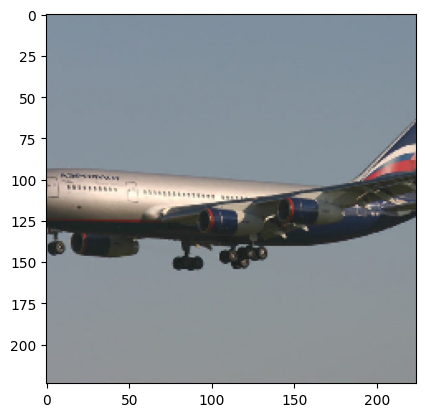

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[9.9999905e-01 9.5585415e-07 8.9214214e-10]]


In [ ]:
from matplotlib import pyplot as plt
test_image_path = "/content/dataset/Dataset/test/airplanes/airplane5.jpg"
img = image.load_img(test_image_path, target_size=(224, 224))
plt.imshow(img)
plt.axis()
plt.show()
#convert image into array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.  # Normalize the pixel values
# Make predictions
prediction = model.predict(img_array)
# Print the prediction
print(prediction)